# Regresion Basica: Predecir eficiencia de gasolina

Este libro usa el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) y construye un modelo para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Este ejemplo usa el API `tf.keras` , revise [Esta Guia](https://www.tensorflow.org/guide/keras) para obtener mas detalles.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

## El set de Datos de MPG

El set de datos esta disponible de el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Obtenga los datos
Primero descargue el set de datos.
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [16]:
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

'C:\\Users\\rns_2\\.keras\\datasets\\auto-mpg.data'

Importelo usando pandas.

In [17]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin", "Car name"]

In [18]:
auto = pd.read_csv("auto-mpg.data", names=column_names, na_values="?", comment="\t", sep="\s+", skipinitialspace=True)
auto.head(
)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [19]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


### Limpia los datos

Trata los missings y variables categóricas

In [20]:
# Ver valores nulos
print(auto.isnull().sum())


MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
Car name        0
dtype: int64


In [21]:
# Rellenamos los valores nulos de "Horsepower" con la mediana
auto = auto.fillna(auto["Horsepower"].median())
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [22]:
auto["Car name"].unique()

array(['chevrolet chevelle malibu', 'buick skylark 320',
       'plymouth satellite', 'amc rebel sst', 'ford torino',
       'ford galaxie 500', 'chevrolet impala', 'plymouth fury iii',
       'pontiac catalina', 'amc ambassador dpl', 'dodge challenger se',
       "plymouth 'cuda 340", 'chevrolet monte carlo',
       'buick estate wagon (sw)', 'toyota corona mark ii',
       'plymouth duster', 'amc hornet', 'ford maverick', 'datsun pl510',
       'volkswagen 1131 deluxe sedan', 'peugeot 504', 'audi 100 ls',
       'saab 99e', 'bmw 2002', 'amc gremlin', 'ford f250', 'chevy c20',
       'dodge d200', 'hi 1200d', 'chevrolet vega 2300', 'toyota corona',
       'ford pinto', 'plymouth satellite custom', 'ford torino 500',
       'amc matador', 'pontiac catalina brougham', 'dodge monaco (sw)',
       'ford country squire (sw)', 'pontiac safari (sw)',
       'amc hornet sportabout (sw)', 'chevrolet vega (sw)',
       'pontiac firebird', 'ford mustang', 'mercury capri 2000',
       'opel 1900'

In [23]:
#La columna "Car name" tiene muchas categorías, lo que puede ser problemático para el modelo. Vamos a simplificarla quedándonos solo con la marca del coche.
auto["Car name"] = auto["Car name"].str.split().str[0]


In [24]:
# Arreglamos algunos nombres de marcas para que sean consistentes
auto['Car name'] = auto['Car name'].replace({
    'toyouta': 'toyota',
    'chevy': 'chevrolet',
    'maxda': 'mazda',
    'chevroelt': 'chevrolet',
    'mercedes': 'mercedes-benz',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',   
})

In [25]:
#Pasamos a categorical y luego a números
cat = pd.Categorical(auto['Car name'])
print(dict(enumerate(cat.categories)))

auto['Car name'] = cat.codes  

{0: 'amc', 1: 'audi', 2: 'bmw', 3: 'buick', 4: 'cadillac', 5: 'capri', 6: 'chevrolet', 7: 'chrysler', 8: 'datsun', 9: 'dodge', 10: 'fiat', 11: 'ford', 12: 'hi', 13: 'honda', 14: 'mazda', 15: 'mercedes-benz', 16: 'mercury', 17: 'nissan', 18: 'oldsmobile', 19: 'opel', 20: 'peugeot', 21: 'plymouth', 22: 'pontiac', 23: 'renault', 24: 'saab', 25: 'subaru', 26: 'toyota', 27: 'triumph', 28: 'volkswagen', 29: 'volvo'}


### Divide los datos en train y test

Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

NOTA: El resultado tienen que ser dos datasets

In [26]:
from sklearn.model_selection import train_test_split

# Separar características y etiqueta
X = auto.drop('MPG', axis=1)
y = auto['MPG']
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)


(318, 8)
(80, 8)


### Inspecciona los datos

Revise rapidamente la distribucion conjunta del dataset de entrenamiento mediante un grid de gráficos

IndexError: index 2 is out of bounds for axis 0 with size 2

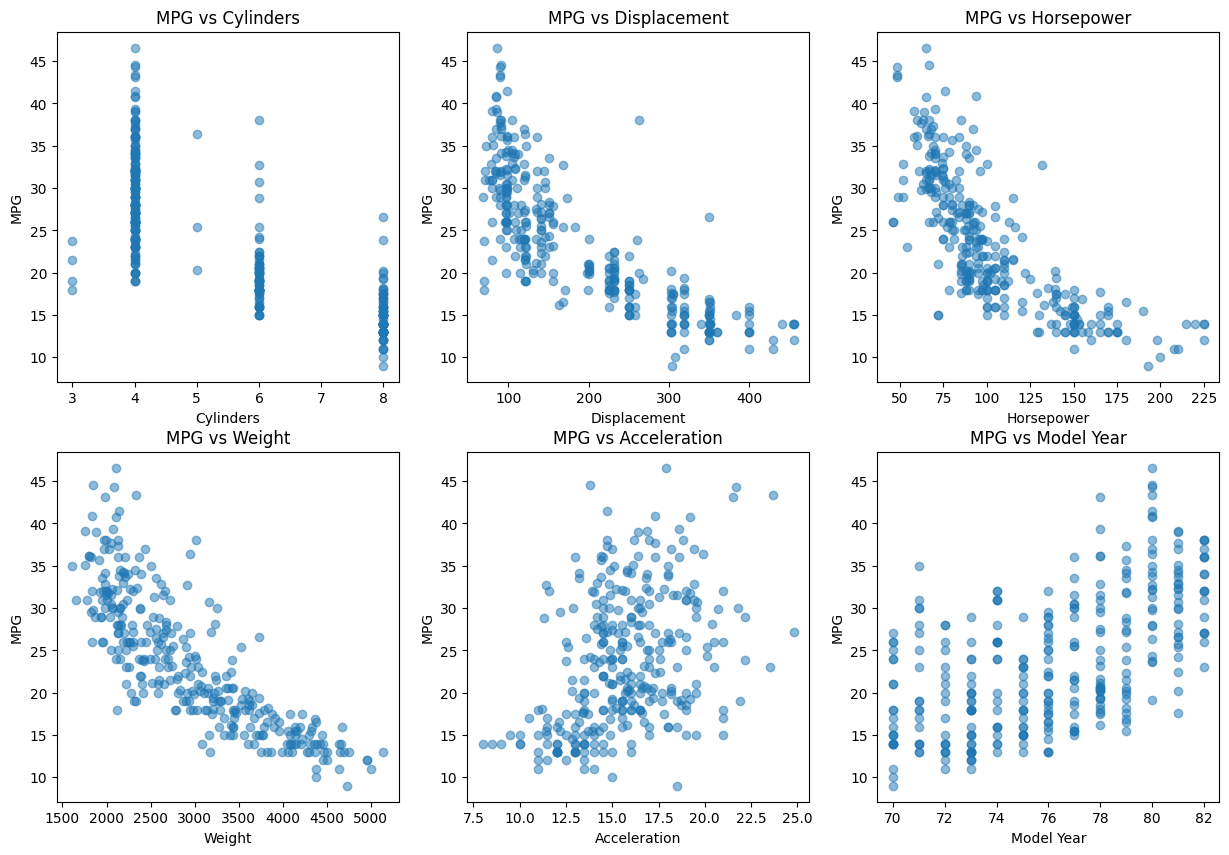

In [28]:
# Grid de gráficos de dispersión
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year','Car Name']

for i, feature in enumerate(features):
    row, col = i // 3, i % 3
    axes[row, col].scatter(X_train[feature], y_train, alpha=0.5)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('MPG')
    axes[row, col].set_title(f'MPG vs {feature}')

plt.tight_layout()
plt.show()

Tambien revise las estadisticas generales:

In [ ]:
train_dataset.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
count,318.000000,318.000000,318.000000,313.000000,318.000000,318.000000,318.000000,318.000000,0.0
mean,23.608176,5.430818,191.904088,103.284345,2969.015723,15.639937,76.103774,1.591195,NaN
std,7.930574,1.684947,102.983802,37.361097,840.617729,2.763269,3.603177,0.811696,NaN
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,NaN
25%,17.500000,4.000000,98.500000,75.000000,2220.000000,13.900000,73.000000,1.000000,NaN
50%,22.450000,4.000000,148.500000,92.000000,2822.500000,15.500000,76.000000,1.000000,NaN
75%,29.725000,6.000000,259.500000,122.000000,3597.250000,17.300000,79.000000,2.000000,NaN
max,46.600000,8.000000,455.000000,225.000000,5140.000000,24.800000,82.000000,3.000000,NaN


### Separa las features del target

Separe el target de las features.

In [14]:
train_labels = train_dataset.pop('MPG')
test_labels = test_dataset.pop('MPG')

NameError: name 'train_dataset' is not defined

### Estandariza los datos

Es una buena práctica estandarizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo podría converger sin estandarizar, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
3,1.524785,1.088481,1.250382,0.551956,-1.317258,-1.693997,-0.728346,NaN
18,-0.849176,-0.921544,-0.409098,-0.998094,-0.412532,-1.693997,1.735632,NaN
376,-0.849176,-0.979805,-0.944414,-1.123002,0.926462,1.636396,1.735632,NaN
248,-0.849176,-0.979805,-1.158541,-1.390663,0.275059,0.526265,1.735632,NaN
177,-0.849176,-0.746759,-0.221737,-0.327159,-0.231587,-0.306333,0.503643,NaN


Estos datos estandarizados es lo que usaremos para entrenar el modelo.

## El modelo

### Construye el modelo

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo.

Por tanto, tendrá tres capas. Una de entrada con activación relu. Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres para las dos primeras capas.

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

In [ ]:
train_norm.shape

(318, 8)

In [ ]:

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=[len(train_dataset.columns)]),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

optimizer = keras.optimizers.RMSprop(0.001)
    
model.compile(loss='mse',
            optimizer=optimizer,
            metrics=['mae', 'mse'])


### Inspeccione el modelo

Use el método `.summary` para imprimir una descripción simple del modelo

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo

Entrene el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

NOTA: recuerda usar los datos normalizados.

In [ ]:
history = model.fit(
    train_norm, train_labels,
    epochs=1000,
    validation_split=0.2,
    verbose=0
)


Entrenamiento completado ✅


Visualice el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`.

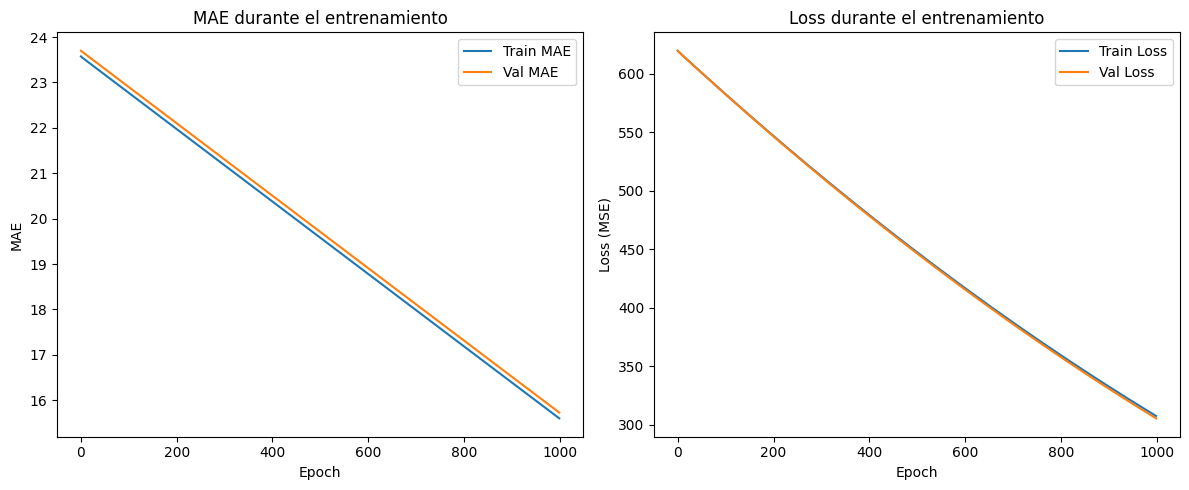

In [ ]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['epoch'], hist['mae'], label='Train MAE')
plt.plot(hist['epoch'], hist['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('MAE durante el entrenamiento')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
plt.plot(hist['epoch'], hist['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss durante el entrenamiento')
plt.legend()

plt.tight_layout()
plt.show()

¿Alguna conclusión respecto a este gráfico?

MAE bajando → el modelo aprende progresivamente a predecir mejor
// Train y Val casi paralelas → el modelo generaliza bien, no memoriza los datos de entrenamiento

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

Ahora prueba el modelo. Coge 10 ejemplos de test y llama a` model.predict`.

In [ ]:
test_predictions = model.predict(test_norm[:10])

print("Predicciones:", test_predictions.flatten())
print("Valores reales:", test_labels[:10].values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicciones: [7.9850683 7.9850683 7.9850683 7.9850683 7.9850683 7.9850683 7.9850683
 7.9850683 7.9850683 7.9850683]
Valores reales: [33. 28. 19. 13. 14. 27. 24. 13. 17. 21.]


### Haz Predicciones

Dibuja en un scatter plot las predicciones de test vs sus true labels.

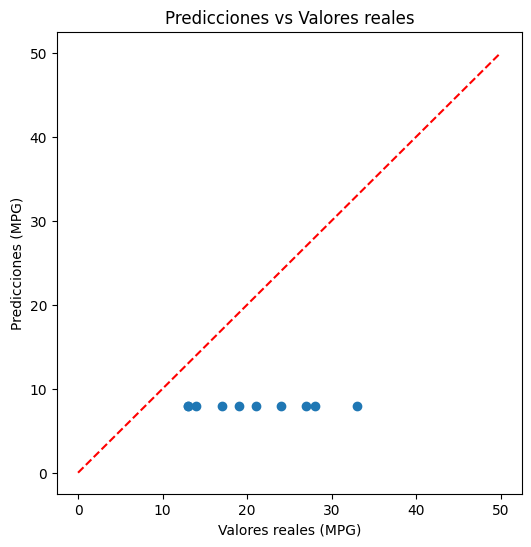

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(test_labels[:10], test_predictions.flatten())
plt.xlabel('Valores reales (MPG)')
plt.ylabel('Predicciones (MPG)')
plt.title('Predicciones vs Valores reales')
plt.plot([0, 50], [0, 50], color='red', linestyle='--')
plt.show()

Parece que nuestro modelo predice razonablemente bien. Echemos un vistazo a la distribución de errores.

Representa los residuos en un histograma

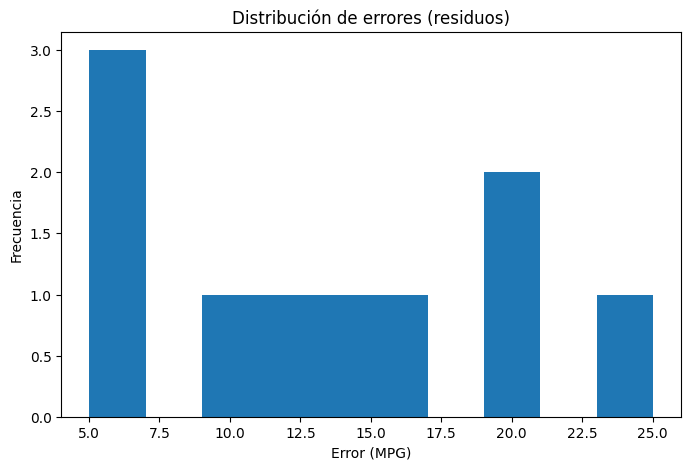

In [ ]:
errores = test_labels[:10].values - test_predictions.flatten()

plt.figure(figsize=(8, 5))
plt.hist(errores, bins=10)
plt.xlabel('Error (MPG)')
plt.ylabel('Frecuencia')
plt.title('Distribución de errores (residuos)')
plt.show()

No es del todo gaussiano, pero podríamos esperar eso porque el número de muestras es muy pequeño.

Guarda tu modelo en un archivo.

In [ ]:
model.save('modelo_mpg.keras')

print("Modelo guardado como 'modelo_mpg.keras' ✅")

Modelo guardado como 'modelo_mpg.keras' ✅


## Conclusion